# Sniffing Behavior Overview — Valence BORIS Recordings

For every valence interaction recording (RI1 & RI2), summarize the social
**sniffing** behaviors scored in BORIS:

- `facial sniffing`
- `body sniffing`
- `anogenital sniffing`

Bouts are loaded and cleaned with `load_clean_boris` from
`resp_helper_functions.py` (keeps only the three sniffing behaviors; by default
keeps only subject-initiated bouts).

Three views, each **split into RI1 vs RI2** panels:
1. Bout **counts** per recording (stacked bars)
2. Total **time spent** sniffing per recording (stacked bars)
3. Per-recording **ethograms** (when each bout occurs over the session)


In [1]:
# --- Core Python ---
import os
import sys
from pathlib import Path

# Ensure notebook-local helper modules are importable
_NB_DIR = Path.cwd()
print(f"currently in {_NB_DIR}")
if (_NB_DIR / "resp_helper_functions.py").exists():
    print("helper functions exist in working directory, adding to sys.path")
    sys.path.insert(0, str(_NB_DIR))
else:
    # Fallback when notebook is launched from workspace root
    _NB_DIR = Path("notebooks/thomas_notebooks/resp_classification").resolve()
    if (_NB_DIR / "resp_helper_functions.py").exists():
        sys.path.insert(0, str(_NB_DIR))
    print("Helper not in cwd; resolved and added to sys.path")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# load_clean_boris and friends
from resp_helper_functions import load_clean_boris

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

# The three sniffing behaviors (BORIS labels are lowercased by load_clean_boris)
SNIFF_BEHAVIORS = ["facial sniffing", "body sniffing", "anogenital sniffing"]
BEHAVIOR_COLORS = {
    "facial sniffing":     "#4C72B0",
    "body sniffing":       "#DD8452",
    "anogenital sniffing": "#55A868",
}

# Keep only subject-initiated bouts (matches the feature-extraction pipeline).
# Set to False to include social_agent-initiated bouts too.
SUBJECT_ONLY = True
print("Setup complete.")


currently in c:\Users\thoma\Code\ResearchCode\respiratory_pilot
Helper not in cwd; resolved and added to sys.path
Libraries loaded successfully
Setup complete.


## BORIS paths (valence RI1 / RI2 only)

In [2]:
# Base path for valence BORIS exports
valence_boris_base = r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\boris_csv_RI1 and RI2"

# Only the interaction recordings (RI1 / RI2). Baselines (BLRI) are excluded here.
boris_paths_valence = {
    "RI1_3_6": os.path.join(valence_boris_base, "RI1_s3_6_p5_3_nRB3_HEEPS.csv"),
    "RI2_3_6": os.path.join(valence_boris_base, "RI2_s3_6_p_5_3_nRB3_2025062.csv"),
    "RI1_4_7": os.path.join(valence_boris_base, "RI1_s4_7_p5_2_nRB3_HEEPS.csv"),
    "RI2_4_7": os.path.join(valence_boris_base, "RI2_s4_7_p5_2_nRB3_HEEPS.csv"),
    "RI1_2_3": os.path.join(valence_boris_base, "RI1_s2_3_p5_3_nRB3_20250622_104059_ss.csv"),
    "RI2_2_3": os.path.join(valence_boris_base, "RI2_s2_3_p5_3_nRB3_20250622_1102116.1_ss.csv"),
    "RI1_4_8": os.path.join(valence_boris_base, "RI1_s4_8_p5_1_nRB3_HEEPS.csv"),
    "RI2_4_8": os.path.join(valence_boris_base, "RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv"),
    "RI1_1_1": os.path.join(valence_boris_base, "RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv"),
    "RI2_1_1": os.path.join(valence_boris_base, "RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv"),
    "RI1_1_2": os.path.join(valence_boris_base, "RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv"),
    "RI2_1_2": os.path.join(valence_boris_base, "RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv"),
    "RI1_2_4": os.path.join(valence_boris_base, "RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv"),
    "RI2_2_4": os.path.join(valence_boris_base, "RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv"),
    "RI2_3_5": os.path.join(valence_boris_base, "RI2_s3_5_p5_4_nRB3_20250621.csv"),
}

print(f"{len(boris_paths_valence)} BORIS recordings")
missing = [k for k, p in boris_paths_valence.items() if not os.path.exists(p)]
print("Missing files:", missing if missing else "none")


15 BORIS recordings
Missing files: none


## Load & tabulate every recording

One long table of all sniffing bouts, plus a per-recording / per-behavior summary.

In [3]:
def session_of(trial_key):
    """RI1 or RI2 from a trial key like 'RI1_3_6'."""
    return trial_key.split("_")[0]

def subject_of(trial_key):
    """Subject id like '3_6' from 'RI1_3_6'."""
    return "_".join(trial_key.split("_")[1:3])

# --- Load every recording into one long, per-bout dataframe ---
bout_frames = []
load_report = []
for trial, path in boris_paths_valence.items():
    df = load_clean_boris(path, subject_only=SUBJECT_ONLY)
    n = len(df)
    load_report.append({"Trial": trial, "Session": session_of(trial),
                        "Subject": subject_of(trial), "n_bouts": n})
    if n == 0:
        print(f"\u26a0\ufe0f  {trial}: 0 sniffing bouts loaded ({os.path.basename(path)})")
        continue
    df = df.copy()
    df["Trial"] = trial
    df["Session"] = session_of(trial)
    df["Subject"] = subject_of(trial)
    bout_frames.append(df)

bouts = pd.concat(bout_frames, ignore_index=True)
print(f"{len(bouts)} total sniffing bouts across {bouts['Trial'].nunique()} recordings")

load_report = pd.DataFrame(load_report)
display(load_report)


390 total sniffing bouts across 15 recordings


,Trial,Session,Subject,n_bouts
0,RI1_3_6,RI1,3_6,16
1,RI2_3_6,RI2,3_6,24
2,RI1_4_7,RI1,4_7,30
3,RI2_4_7,RI2,4_7,2
4,RI1_2_3,RI1,2_3,42
5,RI2_2_3,RI2,2_3,18
6,RI1_4_8,RI1,4_8,29
7,RI2_4_8,RI2,4_8,1
8,RI1_1_1,RI1,1_1,88
9,RI2_1_1,RI2,1_1,3


In [4]:
# --- Per recording x behavior: bout count and total duration ---
summary = (
    bouts.groupby(["Session", "Subject", "Trial", "Behavior"])
    .agg(n_bouts=("Duration", "size"),
         total_dur=("Duration", "sum"),
         mean_dur=("Duration", "mean"))
    .reset_index()
)

# Wide count / duration matrices (rows = recording, cols = behavior), behavior order fixed
count_mat = (bouts.groupby(["Trial", "Behavior"]).size()
             .unstack("Behavior").reindex(columns=SNIFF_BEHAVIORS).fillna(0))
dur_mat = (bouts.groupby(["Trial", "Behavior"])["Duration"].sum()
           .unstack("Behavior").reindex(columns=SNIFF_BEHAVIORS).fillna(0))

print("Bout counts per recording:")
display(count_mat.astype(int))
print("Total sniffing time (s) per recording:")
display(dur_mat.round(1))


Bout counts per recording:


Behavior,facial sniffing,body sniffing,anogenital sniffing
Trial,,,
RI1_1_1,22,46,20
RI1_1_2,15,44,16
RI1_2_3,21,11,10
RI1_2_4,19,23,7
RI1_3_6,3,4,9
RI1_4_7,10,7,13
RI1_4_8,11,9,9
RI2_1_1,0,2,1
RI2_1_2,2,1,0


Total sniffing time (s) per recording:


Behavior,facial sniffing,body sniffing,anogenital sniffing
Trial,,,
RI1_1_1,69.7,130.6,33.3
RI1_1_2,18.1,81.6,37.6
RI1_2_3,17.8,10.0,14.2
RI1_2_4,24.9,42.3,11.4
RI1_3_6,3.1,2.1,17.0
RI1_4_7,14.9,6.5,26.1
RI1_4_8,7.5,9.3,5.5
RI2_1_1,0.0,2.5,1.3
RI2_1_2,0.3,1.0,0.0


## 1. Bout counts per recording (stacked bars, RI1 vs RI2)

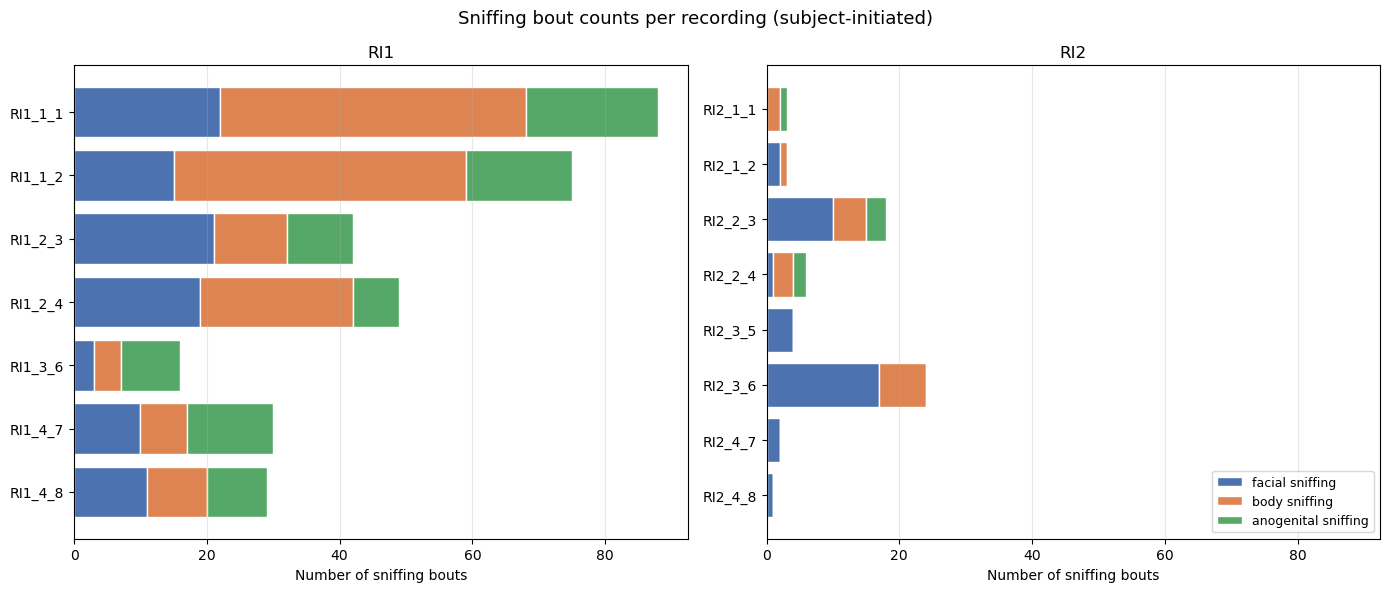

In [5]:
def stacked_panel(ax, mat, trials, title, xlabel):
    """Horizontal stacked bars: one row per recording, segments per behavior."""
    y = np.arange(len(trials))
    left = np.zeros(len(trials))
    for beh in SNIFF_BEHAVIORS:
        vals = mat.reindex(trials)[beh].values
        ax.barh(y, vals, left=left, color=BEHAVIOR_COLORS[beh],
                edgecolor="white", label=beh)
        left += vals
    ax.set_yticks(y)
    ax.set_yticklabels(trials)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)

def sorted_trials(session):
    """Trials for a session, sorted by subject id for stable ordering."""
    ts = [t for t in count_mat.index if session_of(t) == session]
    return sorted(ts, key=lambda t: subject_of(t))

ri1 = sorted_trials("RI1")
ri2 = sorted_trials("RI2")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
stacked_panel(axes[0], count_mat, ri1, "RI1", "Number of sniffing bouts")
stacked_panel(axes[1], count_mat, ri2, "RI2", "Number of sniffing bouts")
axes[1].legend(loc="lower right", fontsize=9, frameon=True)
fig.suptitle(f"Sniffing bout counts per recording ({'subject-initiated' if SUBJECT_ONLY else 'all initiators'})",
             fontsize=13)
fig.tight_layout()
plt.show()


## 2. Total time spent sniffing per recording (stacked bars, RI1 vs RI2)

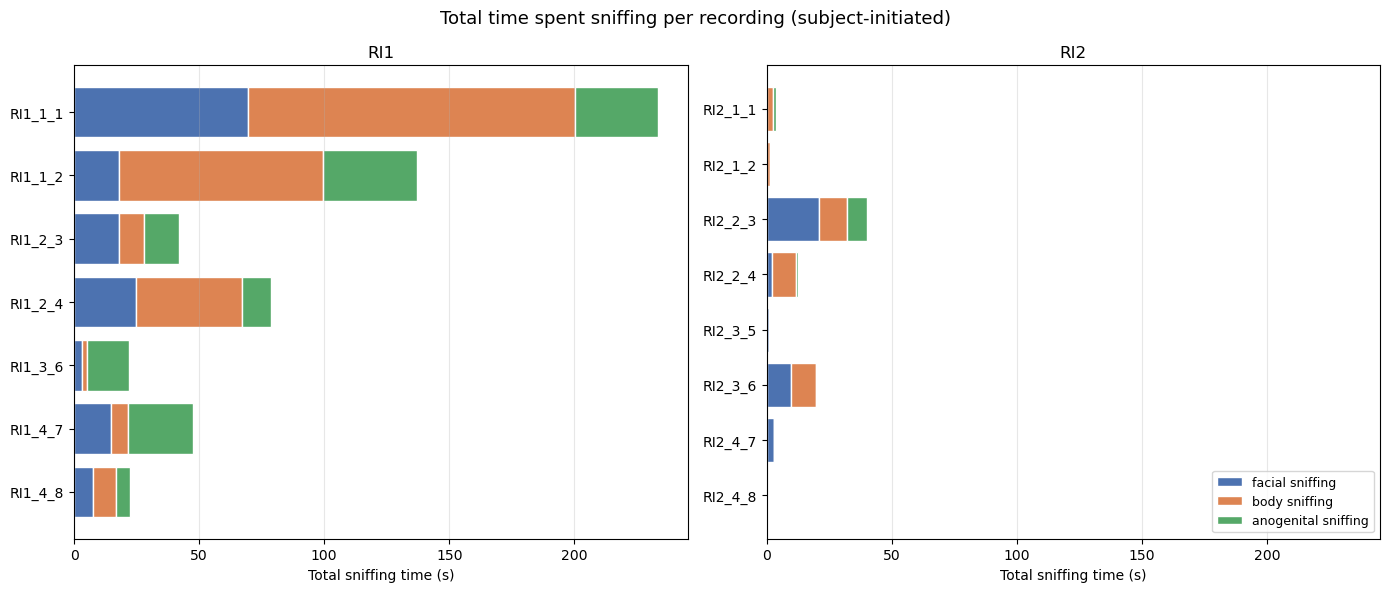

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
stacked_panel(axes[0], dur_mat, ri1, "RI1", "Total sniffing time (s)")
stacked_panel(axes[1], dur_mat, ri2, "RI2", "Total sniffing time (s)")
axes[1].legend(loc="lower right", fontsize=9, frameon=True)
fig.suptitle(f"Total time spent sniffing per recording ({'subject-initiated' if SUBJECT_ONLY else 'all initiators'})",
             fontsize=13)
fig.tight_layout()
plt.show()


## 3. Ethograms — when do bouts happen?

Each row is one behavior; each colored block is one bout (drawn from `Start` to
`Stop`). This shows the temporal structure of sniffing within each session, not
just totals.

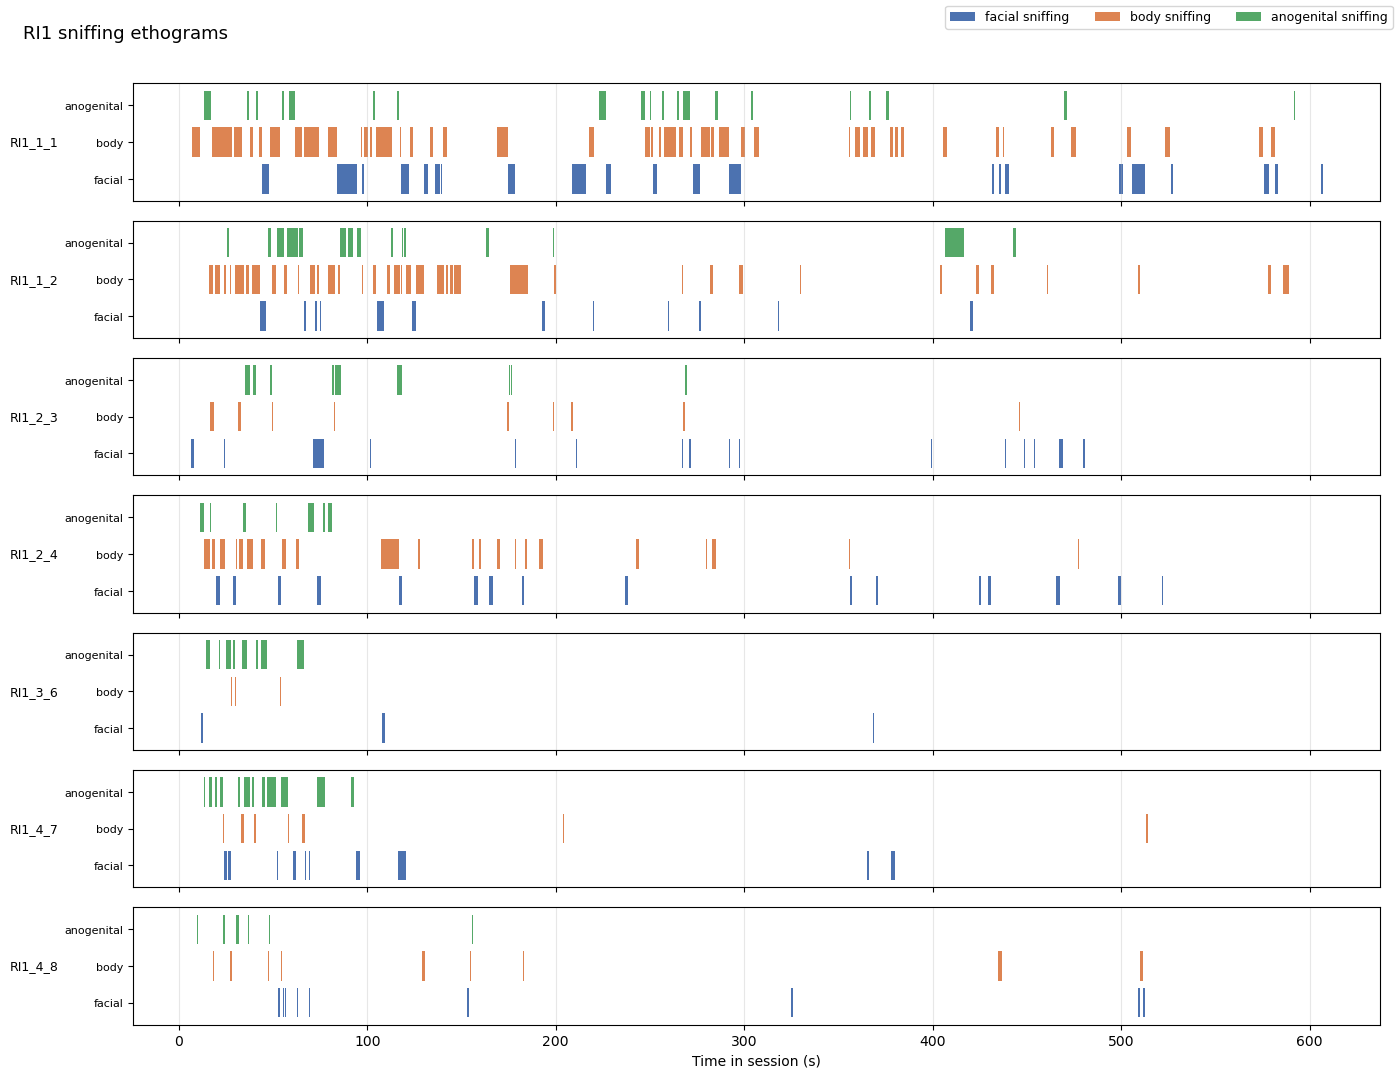

In [7]:
def plot_ethograms(session):
    trials = sorted_trials(session)
    if not trials:
        print(f"No recordings for {session}")
        return
    fig, axes = plt.subplots(len(trials), 1, figsize=(14, 1.4 * len(trials) + 1),
                             sharex=True, squeeze=False)
    axes = axes[:, 0]
    for ax, trial in zip(axes, trials):
        sub = bouts[bouts["Trial"] == trial]
        for i, beh in enumerate(SNIFF_BEHAVIORS):
            spans = sub[sub["Behavior"] == beh]
            if len(spans):
                ax.broken_barh(
                    list(zip(spans["Start"], spans["Duration"])),
                    (i - 0.4, 0.8),
                    facecolors=BEHAVIOR_COLORS[beh],
                )
        ax.set_yticks(range(len(SNIFF_BEHAVIORS)))
        ax.set_yticklabels([b.replace(" sniffing", "") for b in SNIFF_BEHAVIORS], fontsize=8)
        ax.set_ylim(-0.6, len(SNIFF_BEHAVIORS) - 0.4)
        ax.set_ylabel(trial, rotation=0, ha="right", va="center", fontsize=9)
        ax.grid(axis="x", alpha=0.3)
    axes[-1].set_xlabel("Time in session (s)")
    handles = [Patch(facecolor=BEHAVIOR_COLORS[b], label=b) for b in SNIFF_BEHAVIORS]
    fig.legend(handles=handles, loc="upper right", ncol=3, fontsize=9)
    fig.suptitle(f"{session} sniffing ethograms", fontsize=13, x=0.02, ha="left")
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

plot_ethograms("RI1")


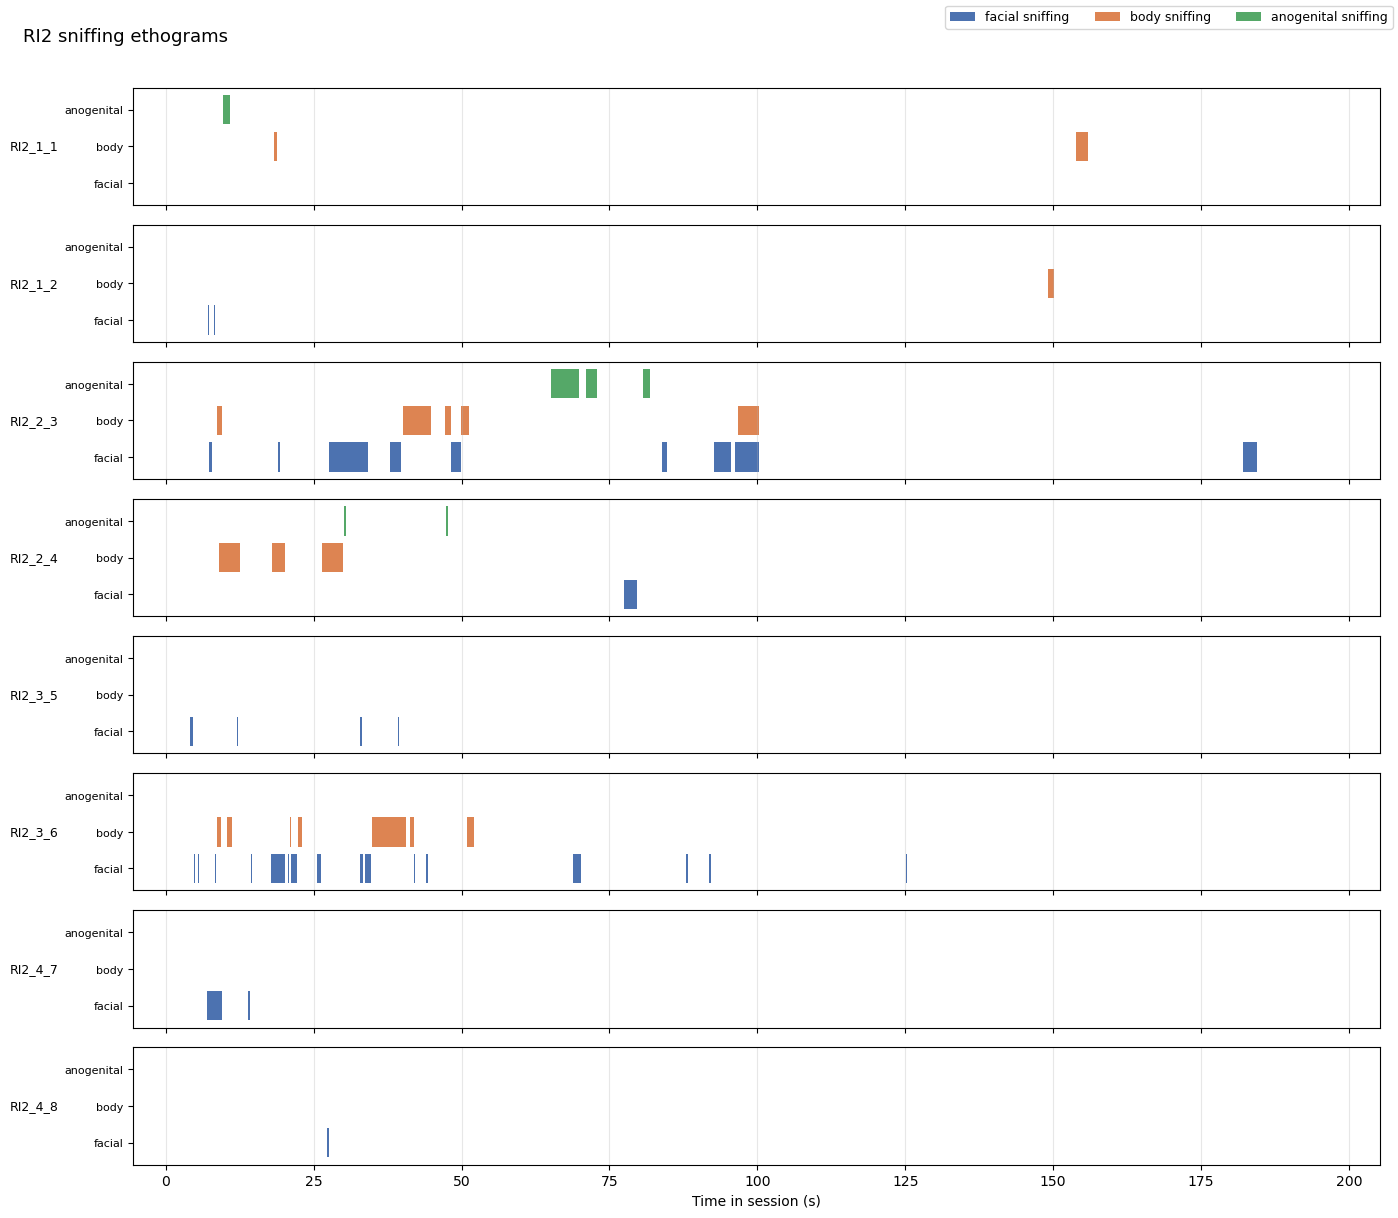

In [8]:
plot_ethograms("RI2")

## Quick takeaways table

Bouts, total time, and dominant behavior per recording — sorted by total
sniffing time so the most/least active recordings are easy to spot.

In [9]:
takeaways = (
    bouts.groupby(["Session", "Subject", "Trial"])
    .agg(n_bouts=("Duration", "size"),
         total_sniff_time=("Duration", "sum"),
         mean_bout_dur=("Duration", "mean"))
    .reset_index()
)
# Dominant behavior (most bouts) per recording
dom = (bouts.groupby(["Trial", "Behavior"]).size()
       .reset_index(name="n")
       .sort_values("n", ascending=False)
       .drop_duplicates("Trial")
       .set_index("Trial")["Behavior"])
takeaways["top_behavior"] = takeaways["Trial"].map(dom)
takeaways = takeaways.sort_values(["Session", "total_sniff_time"], ascending=[True, False])
takeaways["total_sniff_time"] = takeaways["total_sniff_time"].round(1)
takeaways["mean_bout_dur"] = takeaways["mean_bout_dur"].round(2)
display(takeaways.reset_index(drop=True))


,Session,Subject,Trial,n_bouts,total_sniff_time,mean_bout_dur,top_behavior
0,RI1,1_1,RI1_1_1,88,233.5,2.65,body sniffing
1,RI1,1_2,RI1_1_2,75,137.3,1.83,body sniffing
2,RI1,2_4,RI1_2_4,49,78.6,1.60,body sniffing
3,RI1,4_7,RI1_4_7,30,47.5,1.58,anogenital sniffing
4,RI1,2_3,RI1_2_3,42,42.0,1.00,facial sniffing
5,RI1,4_8,RI1_4_8,29,22.4,0.77,facial sniffing
6,RI1,3_6,RI1_3_6,16,22.1,1.38,anogenital sniffing
7,RI2,2_3,RI2_2_3,18,40.1,2.23,facial sniffing
8,RI2,3_6,RI2_3_6,24,19.6,0.82,facial sniffing
9,RI2,2_4,RI2_2_4,6,12.4,2.07,body sniffing
